# CSRNet - Enhanced Version
## With VGG16-only Model, Time Tracking, and Comprehensive Evaluation

In [1]:
import os
import cv2
import cv2 as cv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from scipy.io import loadmat
import matplotlib.pyplot as plt
import time
from datetime import timedelta

In [2]:
def generate_density_map(shape, points, sigma=4):
    H, W = shape
    density = np.zeros((H, W), dtype=np.float32)

    for x, y in points:
        x, y = int(x), int(y)
        if x >= W or y >= H:
            continue
        density[y, x] += 1

    ksize = int(6 * sigma + 1) | 1  # ensure odd; = 25 for sigma=4
    density = cv2.GaussianBlur(density, (ksize, ksize), sigma)
    return density

In [3]:
class TrancosDataset(Dataset):
    def __init__(self, root, downsample_factor=1):
        self.downsample_factor = downsample_factor
        self.img_dir  = os.path.join(root, "images")
        self.dot_dir  = os.path.join(root, "dots")
        self.mask_dir = os.path.join(root, "ground-truth")

        self.images = sorted([f for f in os.listdir(self.img_dir) if f.endswith(".jpg")])

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path  = os.path.join(self.img_dir,  img_name)
        dot_path  = os.path.join(self.dot_dir,  img_name.replace(".jpg", ".txt"))
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", "mask.mat"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(
            img,
            (img.shape[1] // self.downsample_factor,
             img.shape[0] // self.downsample_factor)
        )

        h, w, _ = img.shape
        h_pad = (8 - h % 8) % 8
        w_pad = (8 - w % 8) % 8
        if h_pad > 0 or w_pad > 0:
            img = cv2.copyMakeBorder(img, 0, h_pad, 0, w_pad, cv2.BORDER_REFLECT)
        h, w = img.shape[:2]

        dot_path = os.path.join(self.dot_dir, img_name.replace(".jpg", "dots.png"))
        dot_img = cv2.imread(dot_path, cv2.IMREAD_COLOR)  # read as BGR
        if dot_img is not None:
            r = dot_img[:, :, 2]  # red channel in BGR
            g = dot_img[:, :, 1]
            b = dot_img[:, :, 0]
            red_mask = (r > 100) & (g < 50) & (b < 50)
            ys, xs = np.where(red_mask)
            xs = xs / self.downsample_factor
            ys = ys / self.downsample_factor
            points = np.stack([xs, ys], axis=1).astype(np.float32) if len(xs) > 0 else np.zeros((0, 2), dtype=np.float32)
        else:
            points = np.zeros((0, 2), dtype=np.float32)

        # --- Mask ---
        mat  = loadmat(mask_path)
        mask = mat["BW"]
        mask = cv2.resize(mask.astype(np.float32), (w, h))
        mask = (mask > 0).astype(np.float32)

        img = (img * mask[:, :, None]).astype(np.uint8)

        # --- Density map ---
        density = generate_density_map((h, w), points)
        density = cv2.resize(density, (w // 8, h // 8))

        if density.sum() > 0:
            density *= (len(points) / density.sum())

        density *= 100.0

        img     = self.transform(img)
        density = torch.from_numpy(density).unsqueeze(0)

        return img, density

## Model Architectures

In [4]:
class CSRNet(nn.Module):
    """Original CSRNet with VGG16 frontend + dilated convolution backend"""
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.frontend = nn.Sequential(*list(vgg.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(128,  64, 3, padding=2, dilation=2), nn.ReLU()
        )

        self.output = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output(x)


class VGG16Only(nn.Module):
    """VGG16-only model (no dilated convolution backend)"""
    def __init__(self,layers=23):
        super().__init__()
        self.layers = layers
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.frontend = nn.Sequential(*list(vgg.children())[:self.layers])
        
        # Direct output from VGG16 features (512 channels)
        self.output = nn.Conv2d(512, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        return self.output(x)

## Data Loading

In [10]:
DATA_ROOT = "TRANCOS - edited"

downsample_factor = 1  # adjust for memory constraints

train_ds = TrancosDataset(os.path.join(DATA_ROOT, "train_data"), downsample_factor=downsample_factor)
test_ds  = TrancosDataset(os.path.join(DATA_ROOT, "test_data"),  downsample_factor=downsample_factor)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print("Train:", len(train_ds), "\nTest:", len(test_ds))

Train: 1031 
Test: 213


In [11]:
from torch.amp import autocast, GradScaler
scaler = GradScaler()

## Training Function with Time Tracking

In [ ]:
def train_model(model, model_name, epochs=50, save_path=None,frontend_unfrozen_epoch=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    criterion = nn.MSELoss()
    
    train_losses = []
    epoch_times = []
    
    # Freeze frontend initially
    for param in model.frontend.parameters():
        param.requires_grad = False
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    # Start overall training timer
    training_start_time = time.time()
    
    for epoch in range(epochs):
        epoch_start_time = time.time()
        
        model.train()
        total_loss = 0
        
        # Unfreeze frontend after epoch desired no of epochs
        if epoch == frontend_unfrozen_epoch:
            print("\n Unfreezing VGG16 frontend layers...\n")
            for param in model.frontend.parameters():
                param.requires_grad = True

        for i, (img, density) in enumerate(train_loader):
            img     = img.to(device)
            density = density.to(device)

            with autocast('cuda'):
                pred = model(img)
                loss = criterion(pred, density)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

            if i % (len(train_loader) // 2) == 0:
                print(f"Epoch {epoch+1}/{epochs} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)
        
        # Track epoch time
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        
        print(f"Epoch {epoch+1} done | Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s\n")
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"Total Training Time: {str(timedelta(seconds=int(total_training_time)))}")
    print(f"Average Epoch Time: {np.mean(epoch_times):.2f}s")
    print(f"{'='*60}\n")
    
    # Save model 
    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f"Model saved to {save_path}")
    
    return {
        'train_losses': train_losses,
        'epoch_times': epoch_times,
        'total_time': total_training_time,
        'avg_epoch_time': np.mean(epoch_times)
    }

## Train Original CSRNet Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csrnet_model = CSRNet().to(device)
print(device)
csrnet_results = train_model(
    csrnet_model, 
    "CSRNet (VGG16 + Dilated Convolutions)",
    epochs=50,
    save_path="csrnet_trancos.pth",
    frontend_unfrozen_epoch=20
)

#training this model for 20 epochs with frontend frozen and then unfreezing it for the remaining 30 epochs. Uses the concept of transfer learning by freezing the pretrained VGG16 layers initially to allow the dilated convolution backend to learn meaningful features before fine-tuning the entire network.


cuda

Training CSRNet (VGG16 + Dilated Convolutions)
Epoch 1/50 | Batch 0/65 | Loss: 28.4091
Epoch 1 done | Avg Loss: 23.1475 | Time: 151.31s

Epoch 2/50 | Batch 0/65 | Loss: 23.3144
Epoch 2 done | Avg Loss: 18.6564 | Time: 153.70s

Epoch 3/50 | Batch 0/65 | Loss: 12.2150
Epoch 3 done | Avg Loss: 15.0977 | Time: 184.26s

Epoch 4/50 | Batch 0/65 | Loss: 14.0735
Epoch 4 done | Avg Loss: 13.3889 | Time: 191.76s

Epoch 5/50 | Batch 0/65 | Loss: 12.1838
Epoch 5 done | Avg Loss: 12.5851 | Time: 225.97s

Epoch 6/50 | Batch 0/65 | Loss: 12.2538
Epoch 6 done | Avg Loss: 11.9621 | Time: 121.19s

Epoch 7/50 | Batch 0/65 | Loss: 11.9971
Epoch 7 done | Avg Loss: 11.3647 | Time: 100.14s

Epoch 8/50 | Batch 0/65 | Loss: 11.6977
Epoch 8 done | Avg Loss: 10.5063 | Time: 103.82s

Epoch 9/50 | Batch 0/65 | Loss: 9.2541
Epoch 9 done | Avg Loss: 9.3932 | Time: 128.14s

Epoch 10/50 | Batch 0/65 | Loss: 8.0639
Epoch 10 done | Avg Loss: 7.7710 | Time: 132.07s

Epoch 11/50 | Batch 0/65 | Loss: 6.7783
Epoch 11 

## Train VGG16-Only Model

In [16]:
vgg16_model = VGG16Only().to(device)
print(device)
vgg16_results = train_model(
    vgg16_model,
    "VGG16-Only (No Backend)",
    epochs=45,
    save_path="vgg16only_trancos.pth"
)

cuda

Training VGG16-Only (No Backend)
Epoch 1/45 | Batch 0/65 | Loss: 24.5211
Epoch 1 done | Avg Loss: 26.3037 | Time: 30.93s

Epoch 2/45 | Batch 0/65 | Loss: 19.3552
Epoch 2 done | Avg Loss: 25.1774 | Time: 32.78s

Epoch 3/45 | Batch 0/65 | Loss: 24.8904
Epoch 3 done | Avg Loss: 24.2861 | Time: 31.50s

Epoch 4/45 | Batch 0/65 | Loss: 23.5559
Epoch 4 done | Avg Loss: 23.6422 | Time: 31.30s

Epoch 5/45 | Batch 0/65 | Loss: 22.2092
Epoch 5 done | Avg Loss: 23.0422 | Time: 31.60s

Epoch 6/45 | Batch 0/65 | Loss: 22.9526
Epoch 6 done | Avg Loss: 22.5251 | Time: 31.49s

Epoch 7/45 | Batch 0/65 | Loss: 22.1752
Epoch 7 done | Avg Loss: 22.2247 | Time: 31.41s

Epoch 8/45 | Batch 0/65 | Loss: 19.5055
Epoch 8 done | Avg Loss: 21.8316 | Time: 31.41s

Epoch 9/45 | Batch 0/65 | Loss: 20.5863
Epoch 9 done | Avg Loss: 21.5481 | Time: 31.59s

Epoch 10/45 | Batch 0/65 | Loss: 22.4144
Epoch 10 done | Avg Loss: 21.2879 | Time: 31.57s


 Unfreezing VGG16 frontend layers...

Epoch 11/45 | Batch 0/65 | Los

## Training Comparison Visualization

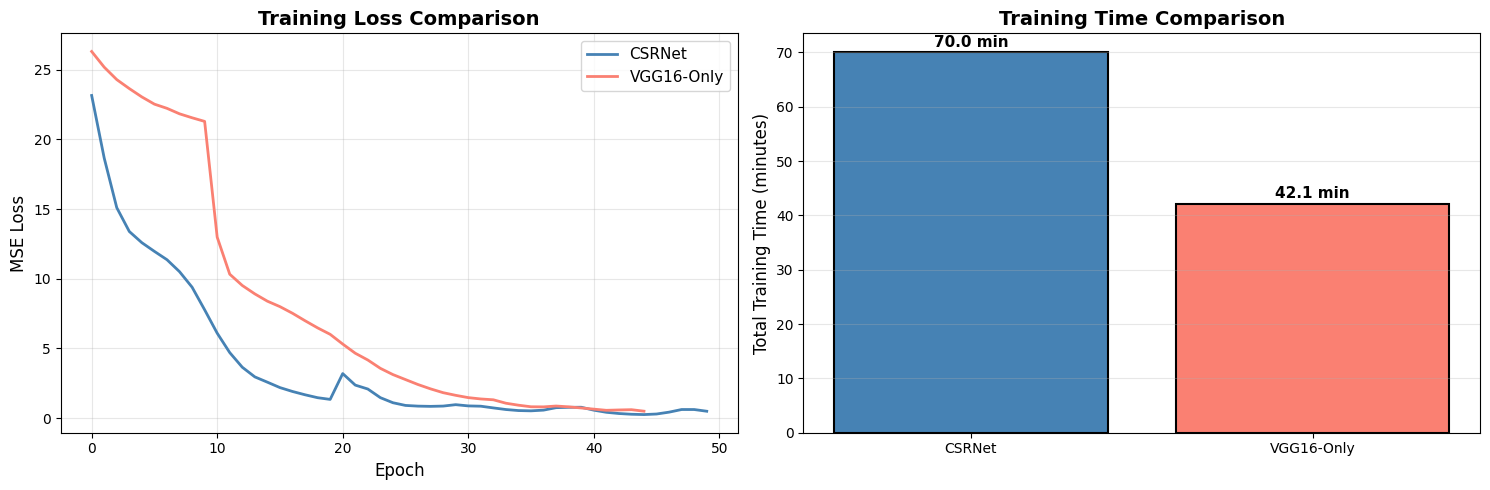


📊 Training comparison saved as 'training_comparison.png'


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss comparison
axes[0].plot(csrnet_results['train_losses'], label='CSRNet', linewidth=2, color='steelblue')
axes[0].plot(vgg16_results['train_losses'], label='VGG16-Only', linewidth=2, color='salmon')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Time comparison
models = ['CSRNet', 'VGG16-Only']
times = [csrnet_results['total_time']/60, vgg16_results['total_time']/60]  # Convert to minutes
colors = ['steelblue', 'salmon']
bars = axes[1].bar(models, times, color=colors, edgecolor='black', linewidth=1.5)
for bar, time_val in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{time_val:.1f} min', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total Training Time (minutes)', fontsize=12)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Training comparison saved as 'training_comparison.png'")

## Evaluation Function with Comprehensive Metrics

In [18]:
def evaluate_model(model, model_name, test_loader, device):
    """
    Evaluate model and compute comprehensive metrics
    
    Returns:
        Dictionary with evaluation metrics and predictions
    """
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}\n")
    
    model.eval()
    gt_counts = []
    pred_counts = []
    
    eval_start_time = time.time()
    
    with torch.no_grad():
        for img, density in test_loader:
            img = img.to(device)
            pred = model(img)
            pred_counts.append(pred.sum().item() / 100.0)
            gt_counts.append(density.sum().item() / 100.0)
    
    eval_time = time.time() - eval_start_time
    
    gt_counts   = np.array(gt_counts)
    pred_counts = np.array(pred_counts)

    # Calculate metrics
    mae  = np.mean(np.abs(pred_counts - gt_counts))
    mse  = np.mean((pred_counts - gt_counts) ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((pred_counts - gt_counts) / (gt_counts + 1e-6))) * 100
    r2   = 1 - np.sum((pred_counts - gt_counts) ** 2) / np.sum((gt_counts - gt_counts.mean()) ** 2)
    

    max_error = np.max(np.abs(pred_counts - gt_counts))
    median_ae = np.median(np.abs(pred_counts - gt_counts))
    
    print(f"Evaluation Time: {eval_time:.2f}s")
    print(f"\nMetrics:")
    print(f"  MAE  (Mean Absolute Error):     {mae:.2f} vehicles")
    print(f"  Median AE:                      {median_ae:.2f} vehicles")
    print(f"  RMSE (Root Mean Sq. Error):     {rmse:.2f} vehicles")
    print(f"  MAPE (Mean % Error):            {mape:.2f}%")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")
    print(f"  Max Error:                      {max_error:.2f} vehicles")
    print(f"{'='*60}\n")
    
    return {
        'gt_counts': gt_counts,
        'pred_counts': pred_counts,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'r2': r2,
        'max_error': max_error,
        'median_ae': median_ae,
        'eval_time': eval_time
    }

## Evaluate Both Models

In [19]:
# Load and evaluate CSRNet
csrnet_model.load_state_dict(torch.load("csrnet_trancos.pth", weights_only=True))
csrnet_eval = evaluate_model(csrnet_model, "CSRNet", test_loader, device)

# Load and evaluate VGG16-Only
vgg16_model.load_state_dict(torch.load("vgg16only_trancos.pth", weights_only=True))
vgg16_eval = evaluate_model(vgg16_model, "VGG16-Only", test_loader, device)


Evaluating CSRNet

Evaluation Time: 26.54s

Metrics:
  MAE  (Mean Absolute Error):     97.82 vehicles
  Median AE:                      103.26 vehicles
  RMSE (Root Mean Sq. Error):     105.04 vehicles
  MAPE (Mean % Error):            18.73%
  R²   (Coefficient of Determination): 0.5287
  Max Error:                      202.92 vehicles


Evaluating VGG16-Only

Evaluation Time: 15.31s

Metrics:
  MAE  (Mean Absolute Error):     20.77 vehicles
  Median AE:                      23.39 vehicles
  RMSE (Root Mean Sq. Error):     25.40 vehicles
  MAPE (Mean % Error):            3.61%
  R²   (Coefficient of Determination): 0.9724
  Max Error:                      54.47 vehicles



## Comprehensive Evaluation Visualization

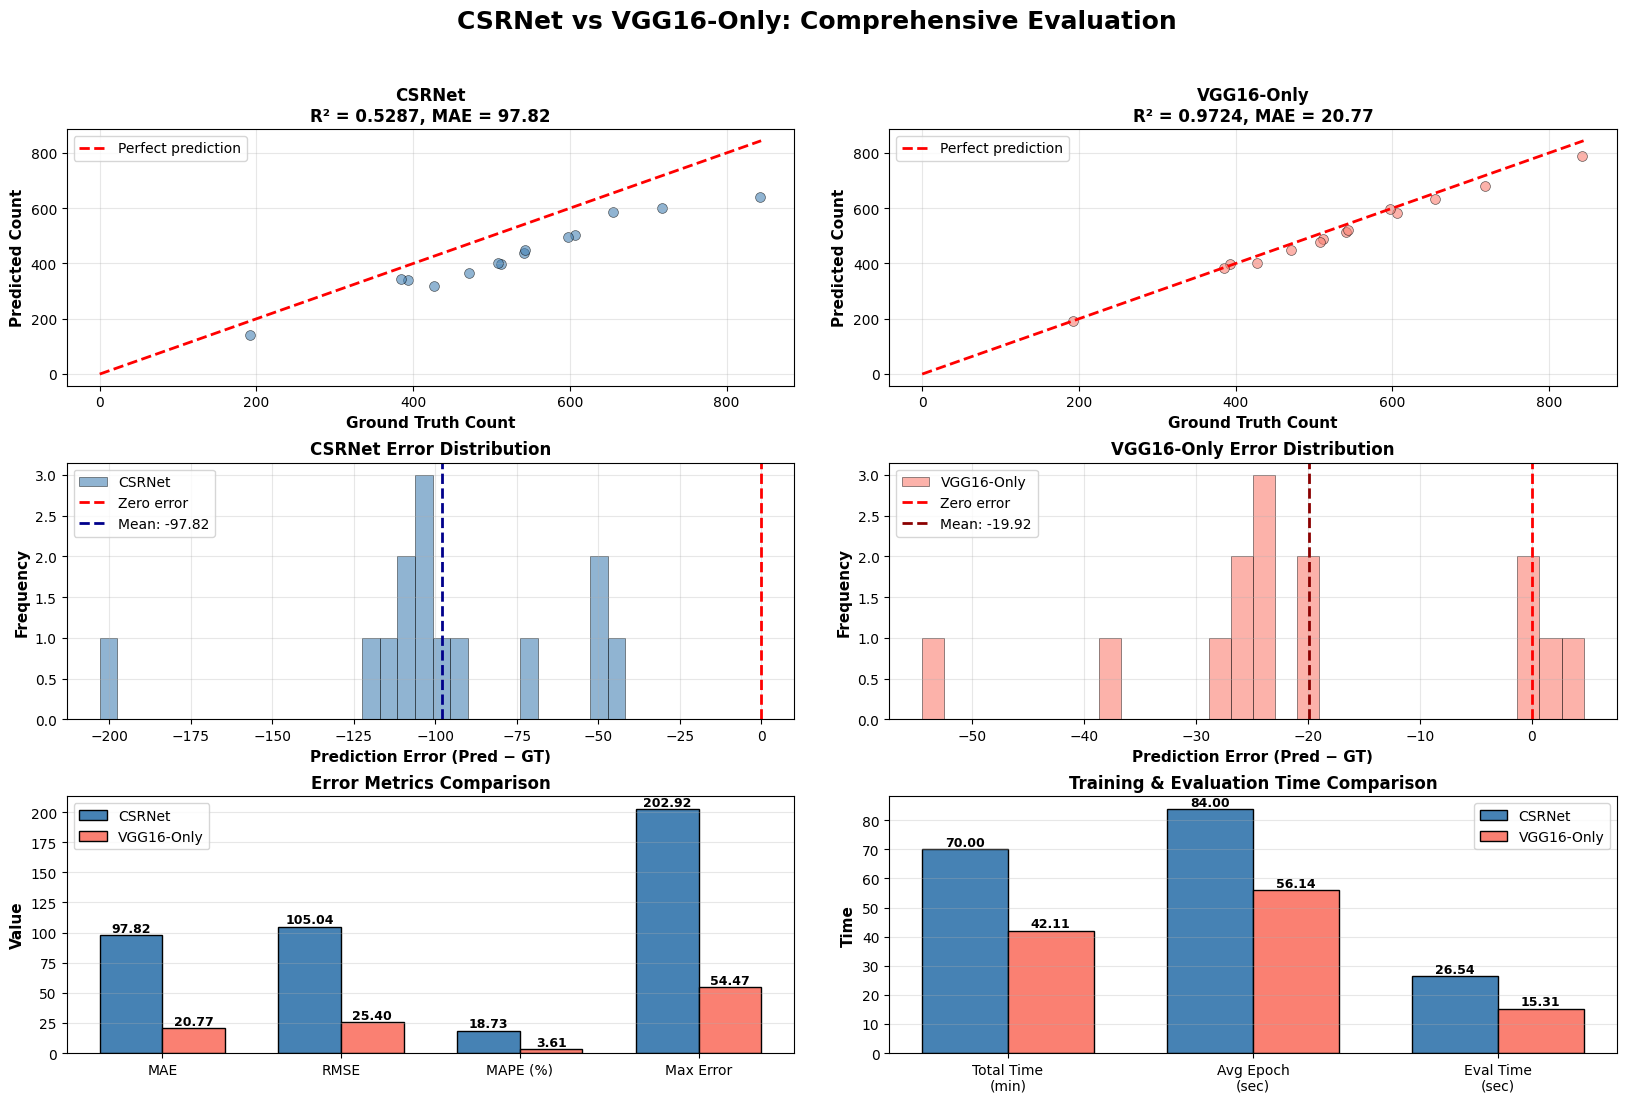


📊 Comprehensive evaluation saved as 'comprehensive_evaluation.png'


In [20]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('CSRNet vs VGG16-Only: Comprehensive Evaluation', 
             fontsize=18, fontweight='bold', y=0.98)

#Scatter plots
for idx, (eval_results, name, color) in enumerate([
    (csrnet_eval, 'CSRNet', 'steelblue'),
    (vgg16_eval, 'VGG16-Only', 'salmon')
]):
    ax = fig.add_subplot(gs[0, idx*2:idx*2+2])
    ax.scatter(eval_results['gt_counts'], eval_results['pred_counts'], 
               alpha=0.6, color=color, edgecolors='black', linewidths=0.5, s=50)
    lims = [0, max(eval_results['gt_counts'].max(), eval_results['pred_counts'].max()) + 2]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Ground Truth Count', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Count', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nR² = {eval_results["r2"]:.4f}, MAE = {eval_results["mae"]:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

#Error distributions 
csrnet_errors = csrnet_eval['pred_counts'] - csrnet_eval['gt_counts']
vgg16_errors = vgg16_eval['pred_counts'] - vgg16_eval['gt_counts']

ax = fig.add_subplot(gs[1, 0:2])
ax.hist(csrnet_errors, bins=30, color='steelblue', alpha=0.6, edgecolor='black', 
        linewidth=0.5, label='CSRNet')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(csrnet_errors.mean(), color='darkblue', linestyle='--', linewidth=2, 
           label=f'Mean: {csrnet_errors.mean():.2f}')
ax.set_xlabel('Prediction Error (Pred − GT)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('CSRNet Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 2:4])
ax.hist(vgg16_errors, bins=30, color='salmon', alpha=0.6, edgecolor='black', 
        linewidth=0.5, label='VGG16-Only')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(vgg16_errors.mean(), color='darkred', linestyle='--', linewidth=2, 
           label=f'Mean: {vgg16_errors.mean():.2f}')
ax.set_xlabel('Prediction Error (Pred − GT)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('VGG16-Only Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

#  Metrics comparison 
ax = fig.add_subplot(gs[2, 0:2])
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'Max Error']
csrnet_values = [csrnet_eval['mae'], csrnet_eval['rmse'], 
                 csrnet_eval['mape'], csrnet_eval['max_error']]
vgg16_values = [vgg16_eval['mae'], vgg16_eval['rmse'], 
                vgg16_eval['mape'], vgg16_eval['max_error']]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, csrnet_values, width, label='CSRNet', 
               color='steelblue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, vgg16_values, width, label='VGG16-Only', 
               color='salmon', edgecolor='black', linewidth=1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Value', fontsize=11, fontweight='bold')
ax.set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

#  Training time comparison 
ax = fig.add_subplot(gs[2, 2:4])
time_metrics = ['Total Time\n(min)', 'Avg Epoch\n(sec)', 'Eval Time\n(sec)']
csrnet_times = [csrnet_results['total_time']/60, 
                csrnet_results['avg_epoch_time'],
                csrnet_eval['eval_time']]
vgg16_times = [vgg16_results['total_time']/60, 
               vgg16_results['avg_epoch_time'],
               vgg16_eval['eval_time']]

x = np.arange(len(time_metrics))
bars1 = ax.bar(x - width/2, csrnet_times, width, label='CSRNet', 
               color='steelblue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, vgg16_times, width, label='VGG16-Only', 
               color='salmon', edgecolor='black', linewidth=1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Time', fontsize=11, fontweight='bold')
ax.set_title('Training & Evaluation Time Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(time_metrics, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.savefig('comprehensive_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comprehensive evaluation saved as 'comprehensive_evaluation.png'")

## Visual Predictions Comparison

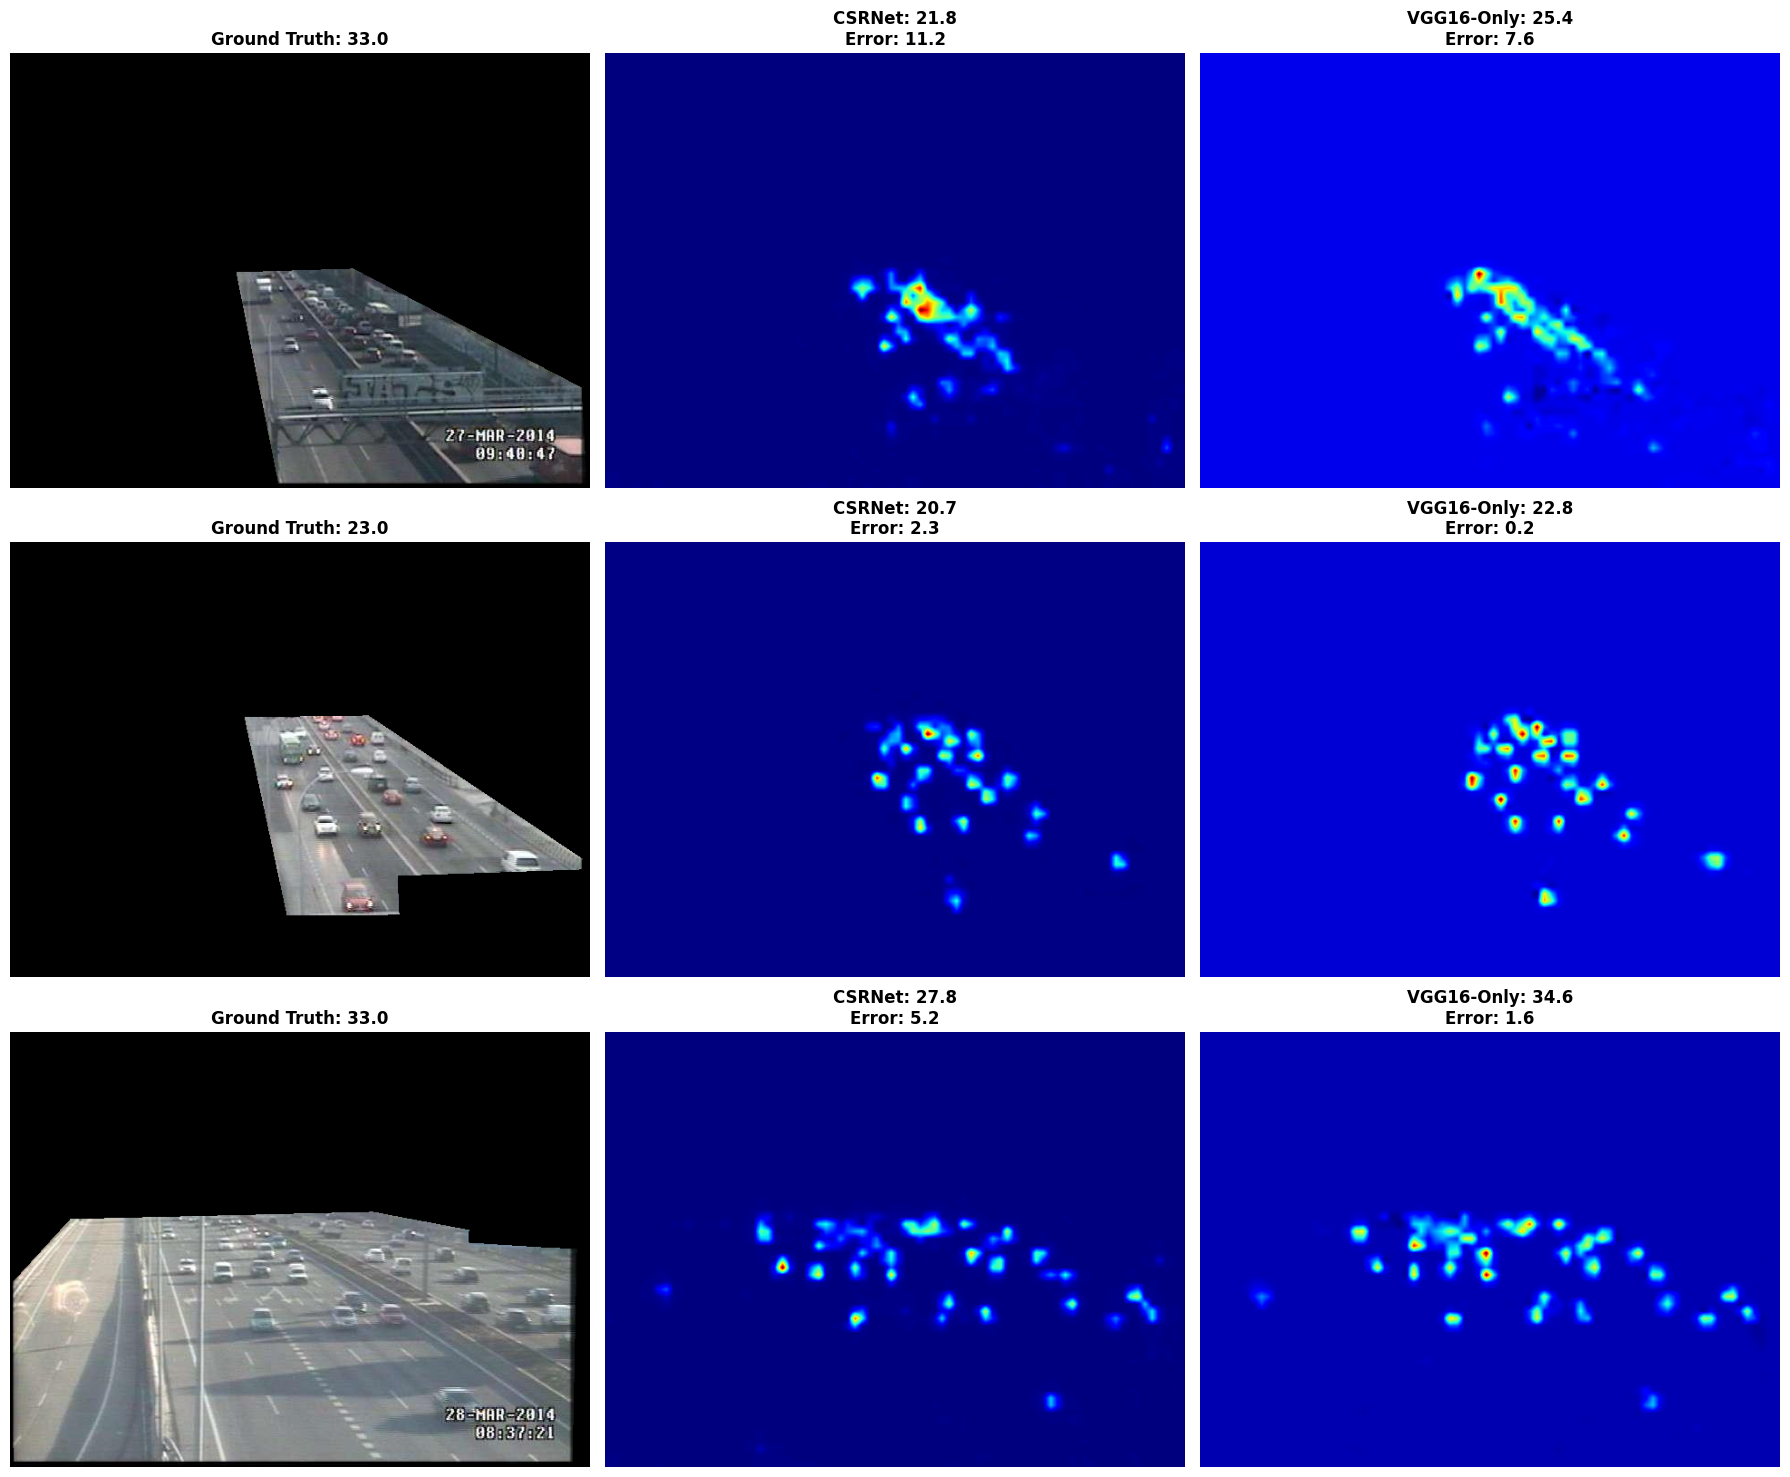


📊 Predictions comparison saved as 'predictions_comparison.png'


In [21]:
import random

csrnet_model.eval()
vgg16_model.eval()

indices = random.sample(range(len(test_ds)), 3)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

with torch.no_grad():
    for row_idx, idx in enumerate(indices):
        img, density = test_ds[idx]
        img_input = img.unsqueeze(0).to(device)
        
        # Get predictions from both models
        csrnet_pred = csrnet_model(img_input)
        vgg16_pred = vgg16_model(img_input)
        
        csrnet_count = csrnet_pred.sum().item() / 100.0
        vgg16_count = vgg16_pred.sum().item() / 100.0
        gt_count = density.sum().item() / 100.0
        
        # Denormalize image
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        
        # Original image
        axes[row_idx, 0].imshow(img_np)
        axes[row_idx, 0].set_title(f'Ground Truth: {gt_count:.1f}', 
                                    fontsize=12, fontweight='bold')
        axes[row_idx, 0].axis('off')
        
        # CSRNet prediction
        csrnet_map = csrnet_pred[0, 0].cpu().numpy()
        csrnet_map = cv2.resize(csrnet_map, (img_np.shape[1], img_np.shape[0]))
        axes[row_idx, 1].imshow(csrnet_map, cmap='jet')
        axes[row_idx, 1].set_title(f'CSRNet: {csrnet_count:.1f}\nError: {abs(csrnet_count-gt_count):.1f}', 
                                    fontsize=12, fontweight='bold')
        axes[row_idx, 1].axis('off')
        
        # VGG16-Only prediction
        vgg16_map = vgg16_pred[0, 0].cpu().numpy()
        vgg16_map = cv2.resize(vgg16_map, (img_np.shape[1], img_np.shape[0]))
        axes[row_idx, 2].imshow(vgg16_map, cmap='jet')
        axes[row_idx, 2].set_title(f'VGG16-Only: {vgg16_count:.1f}\nError: {abs(vgg16_count-gt_count):.1f}', 
                                    fontsize=12, fontweight='bold')
        axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Predictions comparison saved as 'predictions_comparison.png'")